<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
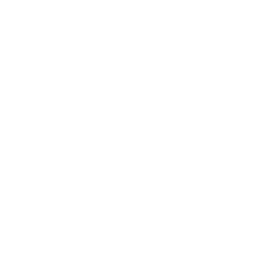
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Kvartalsvis-till-månadsvis interpolering av inskrivning</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Läkemedel / Klinisk verksamhet &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Sammanfattning

Detta genomarbetade exempel konverterar **kvartalsvisa** antal inskrivna i kliniska prövningar till **månadsvisa** uppskattningar med PROC EXPAND, så att resursplanering på sitenivå kan köras i en månadsvis takt. Den syntetiska prövningen omfattar **fyra prövningssiter** i två regioner (Nordamerika och Europa) över **åtta kvartal** (Q1 2024 till Q4 2025), vilket ger **32 kvartalsvisa observationer**. PROC EXPAND interpolerar varje sites serie från kvartalsvis till månadsvis frekvens och omvandlar dessa 32 kvartalsvisa rader till **96 månadsvisa rader**. Antal inskrivna interpoleras med `METHOD=JOIN` (styckvis linjär, vilket håller varje uppskattning icke-negativ) och den löpande kumulativa summan interpoleras med `METHOD=SPLINE`. Den interpolerade månadsvisa serien passerar exakt genom de ursprungliga kvartalsvisa ankarpunkterna, så konverteringen lägger till detaljer inom kvartalet utan att ändra de kvartalssiffror som studien redan rapporterat.

## Datakällor

| Källa | Beskrivning | Poster |
|--------|-------------|---------|
| WORK.ENROLLMENT_QTR | Kvartalsvisa antal inskrivna per site (4 siter x 8 kvartal) | 32 |
| WORK.SITE_MASTER | Site-referens: namn, land, region, PI | 4 |

---

In [1]:
/* --------------------------------------------------------
   Generate quarterly enrollment counts by site.
   4 sites x 8 quarters (Q1-2024 through Q4-2025) = 32 rows.
   A ramp-up curve (slow start, plateau) plus a mild seasonal
   term and small noise produces a realistic enrollment shape.
   -------------------------------------------------------- */
data work.enrollment_qtr;
    CALL streaminit(42);
    format quarter_date yyq7.;
    FÄLT capacity[4] _temporary_ (12 9 14 8);
    GÖR site_num = 1 TILL 4;
        site_id = cat('SITE-', SKRIV_UT_V(site_num, z3.));
        region  = ifc(site_num <= 2, 'NORTH_AMERICA', 'EUROPE');
        base_rate = capacity[site_num];
        GÖR qtr_seq = 0 TILL 7;
            quarter_date = intnx('qtr', '01JAN2024'd, qtr_seq);
            ramp_factor  = 0.3 + 0.7 * (1 - EXP(-0.4 * qtr_seq));
            seasonal_adj = 1 + 0.15 * sin(2 * 3.14159 * qtr_seq / 4);
            noise = round(rand('normal', 0, 1.5), 1);
            enrolled_count = MAX(0,
                round(base_rate * ramp_factor * seasonal_adj + noise, 1));
            UTDATA;
        SLUT;
    SLUT;
    TA_BORT site_num base_rate ramp_factor seasonal_adj noise qtr_seq;
KÖR;

/* Running cumulative enrollment within each site */
PROCEDUR SORTERA data=work.enrollment_qtr;
    EFTER site_id quarter_date;
KÖR;

data work.enrollment_qtr;
    STÄLL_IN work.enrollment_qtr;
    EFTER site_id;
    BEHÅLL_VÄRDE cum_enrolled 0;
    OM first.site_id SÅ cum_enrolled = 0;
    cum_enrolled + enrolled_count;
    cumulative_enrolled = cum_enrolled;
    TA_BORT cum_enrolled;
KÖR;


NOTE: DATA work.enrollment_qtr


NOTE: Wrote work.enrollment_qtr (32 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.enrollment_qtr

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.enrollment_qtr


NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [2]:
/* --------------------------------------------------------
   Site master reference table (4 sites, 2 regions)
   -------------------------------------------------------- */
data work.site_master;
    LÄNGD site_id $8 site_name $40 region $20 country $20 pi_name $30;
    FÄLT names[4] $40 _temporary_ (
        'Metro General Hospital'   'University Medical Center'
        'London Royal Infirmary'   'Berlin Charite Campus'
    );
    FÄLT countries[4] $20 _temporary_ ('USA' 'USA' 'UK' 'Germany');
    GÖR i = 1 TILL 4;
        site_id   = cat('SITE-', SKRIV_UT_V(i, z3.));
        site_name = names[i];
        country   = countries[i];
        region    = ifc(i <= 2, 'NORTH_AMERICA', 'EUROPE');
        pi_name   = cat('Dr. Investigator-', SKRIV_UT_V(i, z2.));
        UTDATA;
    SLUT;
    TA_BORT i;
KÖR;


NOTE: DATA work.site_master


NOTE: Wrote work.site_master (4 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [3]:
/* --------------------------------------------------------
   Baseline quarterly enrollment summary by region
   -------------------------------------------------------- */
PROCEDUR MEDELVÄRDEN data=work.enrollment_qtr n sum mean MAX;
    KLASS region;
    VARIABEL enrolled_count cumulative_enrolled;
    UTDATA out=work.qtr_baseline
        sum(enrolled_count)=total_enrolled
        mean(enrolled_count)=avg_per_quarter
        MAX(cumulative_enrolled)=max_cumulative;
KÖR;

PROCEDUR SKRIV data=work.qtr_baseline noobs;
    TITEL 'Quarterly Enrollment Baseline by Region';
KÖR;


                                                  The MEANS Procedure

                                           Analysis Variable : ENROLLED_COUNT

        REGION                 N Obs            Sum           Mean        Maximum
        -------------------------------------------------------------------------
        EUROPE                    16    120.0000000      7.5000000     13.0000000
        NORTH_AMERICA             16    115.0000000      7.1875000     10.0000000
        -------------------------------------------------------------------------

                                        Analysis Variable : CUMULATIVE_ENROLLED

        REGION                 N Obs            Sum           Mean        Maximum
        -------------------------------------------------------------------------
        EUROPE                    16    493.0000000     30.8125000     81.0000000
        NORTH_AMERICA             16    474.0000000     29.6250000     63.0000000
        ----------------------

NOTE: PROC MEANS
NOTE: Output dataset work.qtr_baseline has 3 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.qtr_baseline

NOTE: PROC PRINT completed: 3 observations printed, 6 variables


Baslinjen bekräftar en balanserad design: varje region bidrar med **16 kvartalsvisa observationer**. Nordamerika skriver in totalt **115 försökspersoner** (medelvärde **7.19** per site-kvartal) och Europa **120** (medelvärde **7.50**). Det största kumulativa antalet som uppnåtts över de åtta kvartalen är **81** försökspersoner (Europas SITE-003) jämfört med **63** i Nordamerika.

---

                                        Quarterly Enrollment Baseline by Region                                         



NOTE: DATA work.traj


NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.traj (32 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=work.traj

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


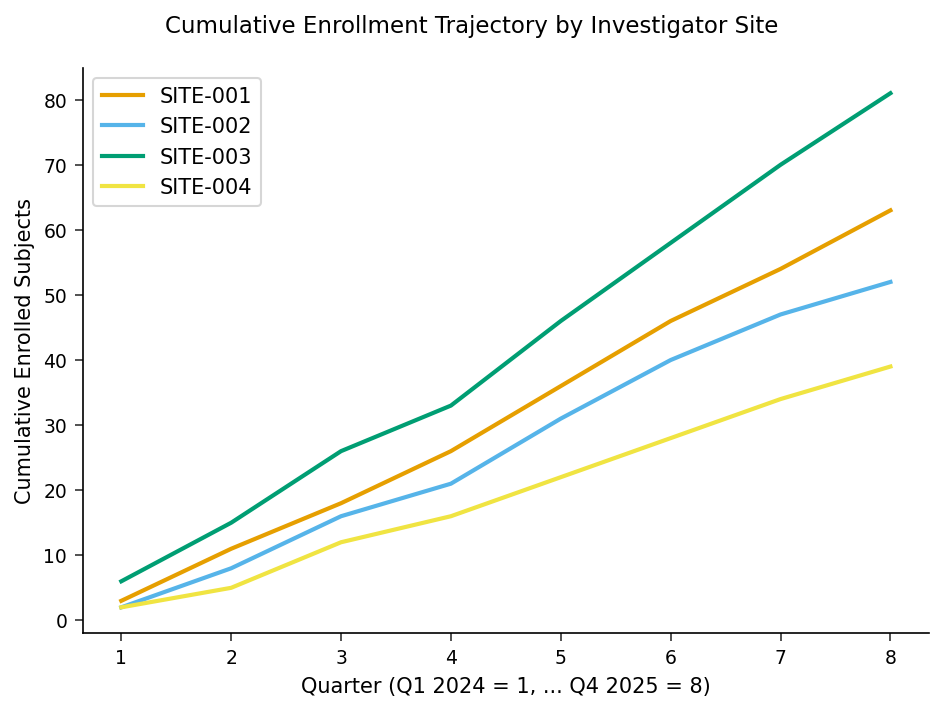

In [4]:
/* --------------------------------------------------------
   Quarterly cumulative-enrollment trajectory by site.
   Plotted against a quarter index (1..8) for a clean axis.
   -------------------------------------------------------- */
data work.traj;
    STÄLL_IN work.enrollment_qtr;
    EFTER site_id;
    BEHÅLL_VÄRDE quarter_index 0;
    OM first.site_id SÅ quarter_index = 0;
    quarter_index + 1;
KÖR;

PROCEDUR SGPLOT data=work.traj;
    SERIES x=quarter_index y=cumulative_enrolled
        / GROUP=site_id LINEATTRS=(thickness=2) MARKERS;
    XAXIS ETIKETT='Quarter (Q1 2024 = 1, ... Q4 2025 = 8)'
        integer VALUES=(1 TILL 8 EFTER 1);
    YAXIS ETIKETT='Cumulative Enrolled Subjects';
    TITEL 'Cumulative Enrollment Trajectory by Investigator Site';
KÖR;


---

In [5]:
/* --------------------------------------------------------
   PROC EXPAND requires the ID variable sorted within each
   BY group, so sort by site then quarter before converting.
   -------------------------------------------------------- */
PROCEDUR SORTERA data=work.enrollment_qtr;
    EFTER site_id quarter_date;
KÖR;


NOTE: PROC SORT data=work.enrollment_qtr

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 5 columns).
NOTE: PROC SORT statement used.


In [6]:
/* --------------------------------------------------------
   Convert quarterly enrollment to monthly estimates.

   FROM=QTR / TO=MONTH on the PROC statement set the input and
   output frequencies; PROC EXPAND interpolates each BY group
   (site) independently along the ID date.

   enrolled_count   -> METHOD=JOIN   (piecewise-linear; the flow
                       value stays non-negative between anchors)
   cumulative_enrolled -> METHOD=SPLINE (smooth monotone curve)
   -------------------------------------------------------- */
PROCEDUR expand data=work.enrollment_qtr
            out=work.enrollment_monthly
            FROM=qtr TILL=month;
    EFTER site_id;
    id quarter_date;
    convert enrolled_count      / observed=average METHOD=JOIN;
    convert cumulative_enrolled / observed=SLUT     METHOD=SPLINE;
KÖR;


                                        Quarterly Enrollment Baseline by Region                                         



NOTE: PROC EXPAND data=work.enrollment_qtr

NOTE: Expand Variables: enrolled_count, cumulative_enrolled
NOTE: Using Python pandas for frequency conversion
NOTE: Output dataset 'work.enrollment_monthly' has 96 observations.
NOTE: PROC EXPAND step completed.


                                        Quarterly Enrollment Baseline by Region                                         



NOTE: DATA work.enrollment_monthly


NOTE: Read 96 rows from work.enrollment_monthly.
NOTE: Wrote work.enrollment_monthly (96 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=work.enrollment_monthly

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


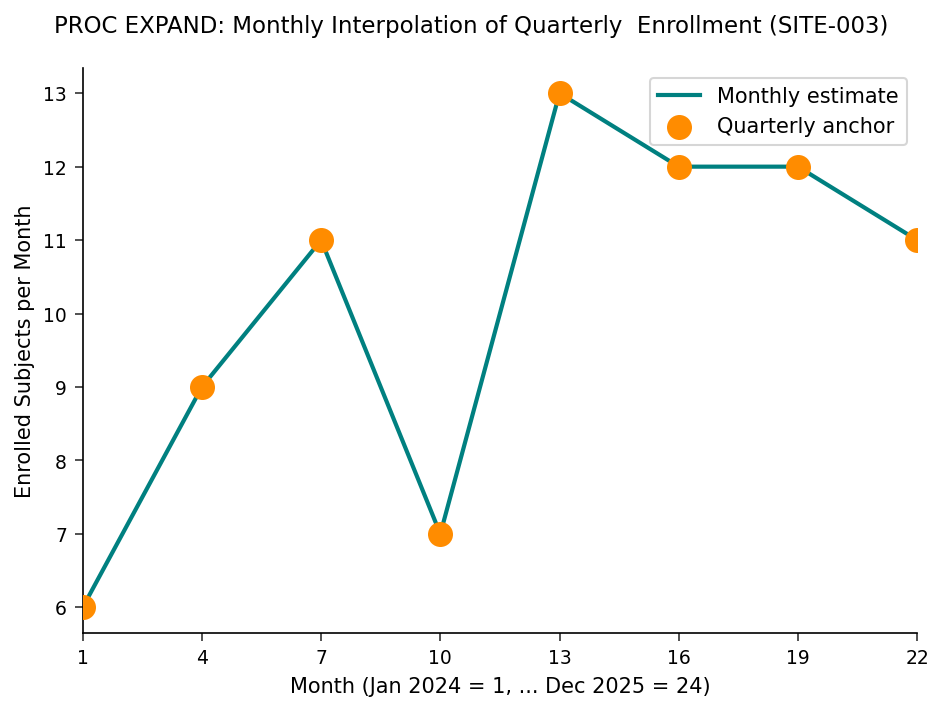

In [7]:
/* --------------------------------------------------------
   The ID variable now carries monthly dates. Re-format it and
   add a within-site month index (1..24) for plotting.
   -------------------------------------------------------- */
data work.enrollment_monthly;
    STÄLL_IN work.enrollment_monthly;
    EFTER site_id;
    format month_date monyy7.;
    month_date = quarter_date;
    BEHÅLL_VÄRDE month_index 0;
    OM first.site_id SÅ month_index = 0;
    month_index + 1;
    /* flag the quarter-anchor months (1, 4, 7, ...) */
    OM mod(month_index - 1, 3) = 0 SÅ anchor = enrolled_count;
    ANNARS anchor = .;
KÖR;

/* Show the conversion for one site: interpolated monthly line
   passing through the original quarterly anchor points. */
PROCEDUR SGPLOT data=work.enrollment_monthly;
    DÄR site_id = 'SITE-003';
    SERIES x=month_index y=enrolled_count
        / LINEATTRS=(thickness=2 color=teal)
          legendlabel='Monthly estimate';
    SCATTER x=month_index y=anchor
        / MARKERATTRS=(SYMBOL=circlefilled size=11 color=darkorange)
          legendlabel='Quarterly anchor';
    XAXIS ETIKETT='Month (Jan 2024 = 1, ... Dec 2025 = 24)'
        integer VALUES=(1 TILL 24 EFTER 3);
    YAXIS ETIKETT='Enrolled Subjects per Month';
    TITEL 'PROC EXPAND: Monthly Interpolation of Quarterly '
        'Enrollment (SITE-003)';
KÖR;


In [8]:
/* --------------------------------------------------------
   Join the monthly estimates to site metadata, then summarize
   monthly enrollment by region.
   -------------------------------------------------------- */
PROCEDUR SQL;
    CREATE TABLE work.enrollment_monthly_region AS
    VÄLJ e.site_id, s.region, e.month_date,
           e.enrolled_count      AS monthly_estimate,
           e.cumulative_enrolled AS cumulative_estimate
    FROM work.enrollment_monthly e
    INNER JOIN work.site_master s
        ON e.site_id = s.site_id
    ORDER EFTER s.region, e.site_id, e.month_date;
QUIT;

PROCEDUR MEDELVÄRDEN data=work.enrollment_monthly_region n sum mean;
    KLASS region;
    VARIABEL monthly_estimate cumulative_estimate;
    UTDATA out=work.region_monthly_summary
        sum(monthly_estimate)=total_monthly_enrolled
        mean(monthly_estimate)=avg_monthly_rate;
KÖR;

PROCEDUR SKRIV data=work.region_monthly_summary noobs;
    TITEL 'Monthly Estimates by Region';
KÖR;


                                        Quarterly Enrollment Baseline by Region                                         

                                        Quarterly Enrollment Baseline by Region                                         

                                                  The MEANS Procedure

                                          Analysis Variable : MONTHLY_ESTIMATE

        REGION                 N Obs            Sum           Mean
        ----------------------------------------------------------
        EUROPE                    44    336.0000000      7.6363636
        NORTH_AMERICA             44    326.0000000      7.4090909
        ----------------------------------------------------------

                                        Analysis Variable : CUMULATIVE_ESTIMATE

        REGION                 N Obs            Sum           Mean
        ----------------------------------------------------------
        EUROPE                    48   1367.0000000   

NOTE: PROC SQL 

NOTE: Table work.enrollment_monthly_region created.
NOTE: PROC SQL statement used.
NOTE: PROC MEANS
NOTE: Output dataset work.region_monthly_summary has 3 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.region_monthly_summary

NOTE: PROC PRINT completed: 3 observations printed, 5 variables


---

### Tolkning

PROC EXPAND konverterade de **32 kvartalsvisa posterna** (4 siter x 8 kvartal) till **96 månadsvisa poster** med frekvenskonvertering längs varje sites datum. Den interpolerade månadsvisa serien passerar exakt genom de ursprungliga kvartalsvisa ankarvärdena, som SITE-003-diagrammet visar: de orange punkterna är de åtta rapporterade kvartalsvisa antalen och den turkosa linjen är den uppdelade månadsvisa uppskattningen som förbinder dem.

På månadsbasis följer de två regionerna varandra tätt. Europa har i genomsnitt **7.64** inskrivna försökspersoner per site-månad och Nordamerika **7.41**, med regionala månadsvisa summor på **336** och **326** försökspersoner över den interpolerade horisonten. Eftersom `METHOD=JOIN` inte extrapolerar bortom det sista kvartalsvisa ankaret bär de sista delkvartalsmånaderna ingen uppskattning och exkluderas från de månadsvisa medelvärdena, vilket är det konservativa valet för framåtblickande planering.

Dessa månadsvisa prognoser låter klinisk verksamhet gå från en kvartalsvis till en månadsvis planeringstakt -- dimensionera läkemedelsleveranser, schemalägga monitoreringsbesök och rapportera inskrivning till Data Safety Monitoring Board -- utan att räkna om någon av de kvartalssiffror som studien redan har låst.

---

In [9]:
/* --------------------------------------------------------
   Export monthly enrollment projections for downstream
   planning tools.
   -------------------------------------------------------- */
PROCEDUR EXPORTERA data=work.enrollment_monthly_region
    OUTFILE='monthly_enrollment_projections.csv'
    DBMS=csv REPLACE;
KÖR;

PROCEDUR EXPORTERA data=work.region_monthly_summary
    OUTFILE='region_monthly_enrollment_summary.csv'
    DBMS=csv REPLACE;
KÖR;


NOTE: PROC EXPORT data=work.enrollment_monthly_region outfile=monthly_enrollment_projections.csv

NOTE: Exported 96 rows to monthly_enrollment_projections.csv.
NOTE: PROC EXPORT data=work.region_monthly_summary outfile=region_monthly_enrollment_summary.csv

NOTE: Exported 3 rows to region_monthly_enrollment_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Konfidentiellt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drivs av <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>